# Text Based Emotion Detection

In [2]:
import sys
print(sys.executable)

C:\Users\hp\anaconda3\envs\nlp_env\python.exe


In [3]:
from sklearn.linear_model import LogisticRegression
from textblob import TextBlob
import scipy
import nltk
import numpy
import pandas

print("Environment is working perfectly 🚀")

Environment is working perfectly 🚀


In [4]:
# Importing Libraries and Datasets
import pandas as pd
import numpy as np
import neattext.functions as nfx

In [5]:
# Loading data visualization packages
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading Dataset 
df= pd.read_csv("tweet_emotions.csv")
df

,tweet_id,Emotion,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...
...,...,...,...
39995,1753918954,neutral,@JohnLloydTaylor
39996,1753919001,love,Happy Mothers Day All my love
39997,1753919005,love,Happy Mother's Day to all the mommies out ther...
39998,1753919043,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [7]:
# Preview
df.head()                                 # see first 5 rows

,tweet_id,Emotion,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [8]:
# Shape
df.shape                              # check rows and columns

(40000, 3)

In [9]:
# Datatypes
df.dtypes                                # check data types

tweet_id     int64
Emotion     object
content     object
dtype: object

In [10]:
# df = df.drop("tweet_id", axis = 1)
# — because tweet_id is already gone.
# tweet_id already removed, so no need to drop again

In [11]:
df.columns                             # column names

Index(['tweet_id', 'Emotion', 'content'], dtype='object')

In [12]:
df.shape

(40000, 3)

In [13]:
df.head(10)

,tweet_id,Emotion,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...
5,1956968477,worry,Re-pinging @ghostridah14: why didn't you go to...
6,1956968487,sadness,"I should be sleep, but im not! thinking about ..."
7,1956968636,worry,Hmmm. http://www.djhero.com/ is down
8,1956969035,sadness,@charviray Charlene my love. I miss you
9,1956969172,sadness,@kelcouch I'm sorry at least it's Friday?


In [14]:
# Checking for the missing values
df.isnull().sum()

tweet_id    0
Emotion     0
content     0
dtype: int64

In [15]:
# Value Count for the Emotions
df['Emotion'].value_counts()

Emotion
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64

<Axes: xlabel='Emotion'>

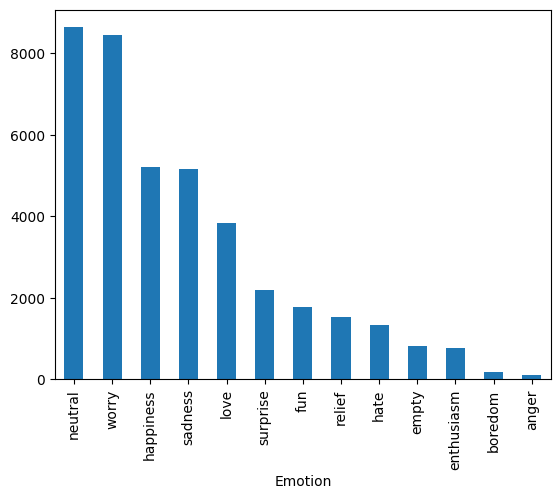

In [16]:
df['Emotion'].value_counts().plot(kind = 'bar')                 # Count number of samples for each emotion class
                                                                # and visualize distribution using bar chart

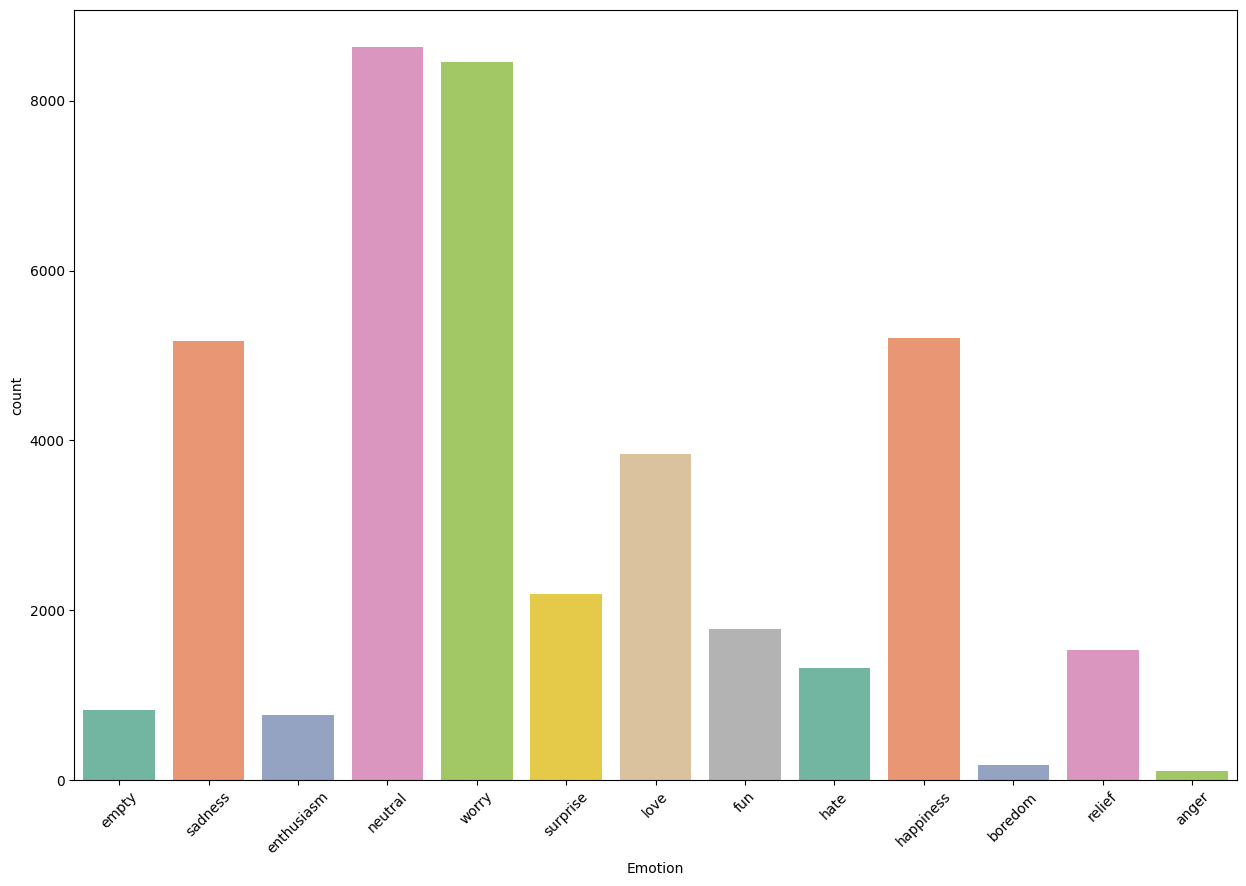

In [17]:
#using Seaborn to Plot
plt.figure(figsize=(15,10))
sns.countplot(x='Emotion', data=df, hue='Emotion', palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.show()                             # Helps identify class imbalance in dataset

# Exploration 
+ Stentiment Analysis
+ Keyword Extraction
    - Keywords for each emotion 
    - worlcloud

In [19]:
!pip install nltk

In [20]:
# Sentiment Analysis
from textblob import TextBlob

In [21]:
# Function to classify text sentiment using TextBlob polarity
def get_sentiment(text):
    
    # Create TextBlob object
    blob = TextBlob(text)
    
    # Extract polarity score (-1 to +1)
    sentiment = blob.sentiment.polarity
    
    # Classify based on polarity value
    if sentiment > 0:
        result = "Positive"
    elif sentiment < 0:
        result = "Negative"
    else:
        result = "Neutral"
        
    return result  # Return sentiment label

In [22]:
# Test Fxn
get_sentiment("I love coding")                 # Test sentiment function on a sample positive sentence

'Positive'

In [23]:
df['Sentiment'] = df['content'].apply(get_sentiment)          # Apply sentiment classification function on text column
                                                              # and create new column 'Sentiment'

In [24]:
# Display first 5 rows to verify dataset structure
df.head(5)

,tweet_id,Emotion,content,Sentiment
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...,Negative
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...,Neutral
2,1956967696,sadness,Funeral ceremony...gloomy friday...,Neutral
3,1956967789,enthusiasm,wants to hang out with friends SOON!,Positive
4,1956968416,neutral,@dannycastillo We want to trade with someone w...,Neutral


In [25]:
# Compare Emotion and Sentiment counts
comparison = df.groupby(['Emotion','Sentiment']).size().reset_index(name='Count')
comparison

,Emotion,Sentiment,Count
0,anger,Negative,34
1,anger,Neutral,41
2,anger,Positive,35
3,boredom,Negative,80
4,boredom,Neutral,56
5,boredom,Positive,43
6,empty,Negative,168
7,empty,Neutral,418
8,empty,Positive,241
9,enthusiasm,Negative,100


<Axes: xlabel='Emotion,Sentiment'>

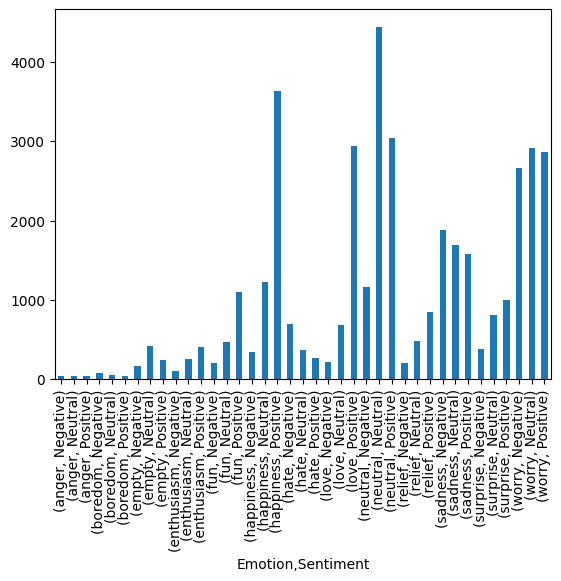

In [26]:
# First Method : Using Matplotlib
# Compare - Emotion vs Sentiment
df.groupby(['Emotion','Sentiment']).size().plot(kind='bar')

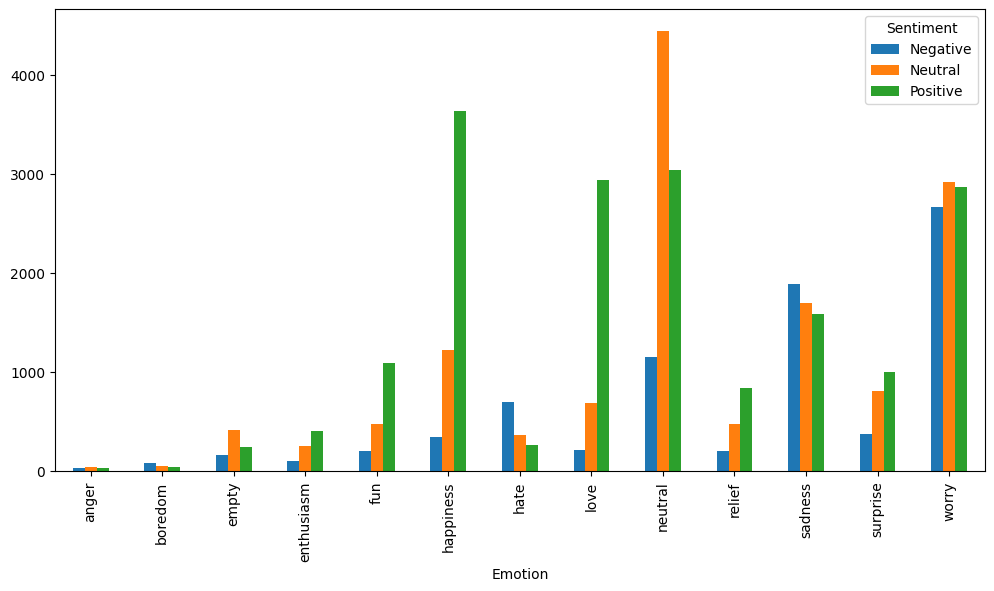

In [27]:
comparison = df.groupby(['Emotion','Sentiment']).size().unstack()
comparison.plot(kind='bar', figsize=(12,6))
plt.show()

# Text Cleaning
+ Remove Noise
    - stopwords
    - special characters
    - punctuations etc.

In [29]:
# Neat Test
dir(nfx)                # list all neattext functions


['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

In [30]:
# Remove stopwords from content column to improve text quality
df['Clean_content'] = df['content'].apply(nfx.remove_stopwords)

In [31]:
# Remove Twitter user handles (e.g., @username) from cleaned text
df['Clean_content'] = df['Clean_content'].apply(nfx.remove_userhandles)

In [32]:
# Remove punctuation marks to reduce noise in text data
df['Clean_content'] = df['Clean_content'].apply(nfx.remove_punctuations)

In [33]:
# Compare original and cleaned text to verify preprocessing
df[['content','Clean_content']]

,content,Clean_content
0,@tiffanylue i know i was listenin to bad habi...,know listenin bad habit earlier started frea...
1,Layin n bed with a headache ughhhh...waitin o...,Layin n bed headache ughhhhwaitin call
2,Funeral ceremony...gloomy friday...,Funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,wants hang friends SOON
4,@dannycastillo We want to trade with someone w...,want trade Houston tickets will
...,...,...
39995,@JohnLloydTaylor,
39996,Happy Mothers Day All my love,Happy Mothers Day love
39997,Happy Mother's Day to all the mommies out ther...,Happy Mothers Day mommies there woman man long...
39998,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,WASSUP BEAUTIFUL FOLLOW ME PEEP NEW HIT SING...


# Keyword Extraction

+ Extract most common words per class of emotion 

In [35]:
# Import Counter to calculate word frequency
from collections import Counter

In [36]:
# Function to extract top N most frequent words from text
def extract_keywords(text, num=50):
    
    # Split text into individual tokens
    tokens = text.split()
    
    # Count word frequency and get top 'num' words
    most_common_tokens = Counter(tokens).most_common(num)
    
    # Return as dictionary
    return dict(most_common_tokens)

In [37]:
# List of Emotions
emotion_list = df['Emotion'].unique().tolist()

In [38]:
emotion_list

['empty',
 'sadness',
 'enthusiasm',
 'neutral',
 'worry',
 'surprise',
 'love',
 'fun',
 'hate',
 'happiness',
 'boredom',
 'relief',
 'anger']

In [39]:
# Extract cleaned text for rows where Emotion is 'fun'
# Convert the result into a Python list
fun_list = df[df['Emotion'] == 'fun']['Clean_content'].tolist()

In [40]:
# Combine all 'fun' emotion texts into a single document
# for keyword frequency analysis
fun_docx = ' '.join(fun_list)

In [41]:
# Display combined 'fun' emotion document for inspection
fun_docx

'Wondering Im awake 7amwriting new songplotting evil secret plots muahahahaoh damn itnot secret anymore   lt3 gonna twitter ) cause amazing lol come canada perform RIP leonardo great mini fiddler crab   out memo looks amazing   OMG Ur alive LOL 2day gone sooo slow Im going insane Grrr tonight   california vintage ahahah BEST dresses want dont ebay (    Umm yeah Thats probably pretty good note self eeeeeewwwwwwww   Thats awesome weekend cant Im moving Sat lot fun finished im not color drawing come   Lettuce amp spinach best cool weather live floridanot luck growing those   know enjoy watching twitter entertaining comic miss BFF rocking Hotel California now   songs stay same Whats next Hmmm Careless whisper   dissapointment hhaha creeped ice cream social good times lars real girl sad movie playing street fighter IV Seth Raped clear DVR getting rid tomorrw   hell yeah missed u nite lol u like opinion wish   burning trees trying dresses spent 2 hours playing TF2 think Im better started unn

In [42]:
# Extract top frequent keywords from 'fun' emotion document
keyword_fun = extract_keywords(fun_docx)

In [43]:
keyword_fun

{'fun': 128,
 'lol': 123,
 'Im': 119,
 'like': 100,
 'good': 90,
 'day': 84,
 'haha': 83,
 'going': 73,
 'im': 71,
 'u': 71,
 'got': 65,
 'think': 59,
 'amp': 58,
 'night': 58,
 'today': 56,
 'know': 54,
 'it': 53,
 'cant': 51,
 'time': 51,
 'great': 47,
 'tonight': 46,
 'love': 44,
 'want': 43,
 'wait': 43,
 '2': 42,
 'right': 42,
 'tomorrow': 41,
 'new': 40,
 'work': 39,
 'funny': 39,
 'gonna': 38,
 'Ill': 37,
 'LOL': 36,
 'yeah': 35,
 'nice': 35,
 'thats': 34,
 'now': 33,
 'home': 33,
 'look': 33,
 'me': 33,
 'cool': 30,
 'better': 30,
 'week': 30,
 'come': 29,
 'Ive': 29,
 'you': 29,
 'way': 29,
 'sleep': 29,
 'getting': 28,
 'morning': 28}

In [44]:
# Function to visualize most common keywords for a given emotion
def plot_most_common_words(mydict, emotion_name):
    
    # Convert dictionary to DataFrame
    df_01 = pd.DataFrame(mydict.items(), columns=['token','count'])
    
    # Set plot size
    plt.figure(figsize=(20,10))
    
    # Add dynamic title
    plt.title("Plot of {} Most Common Keywords".format(emotion_name))
    
    # Create barplot
    sns.barplot(x='token', y='count', data=df_01)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    plt.show()

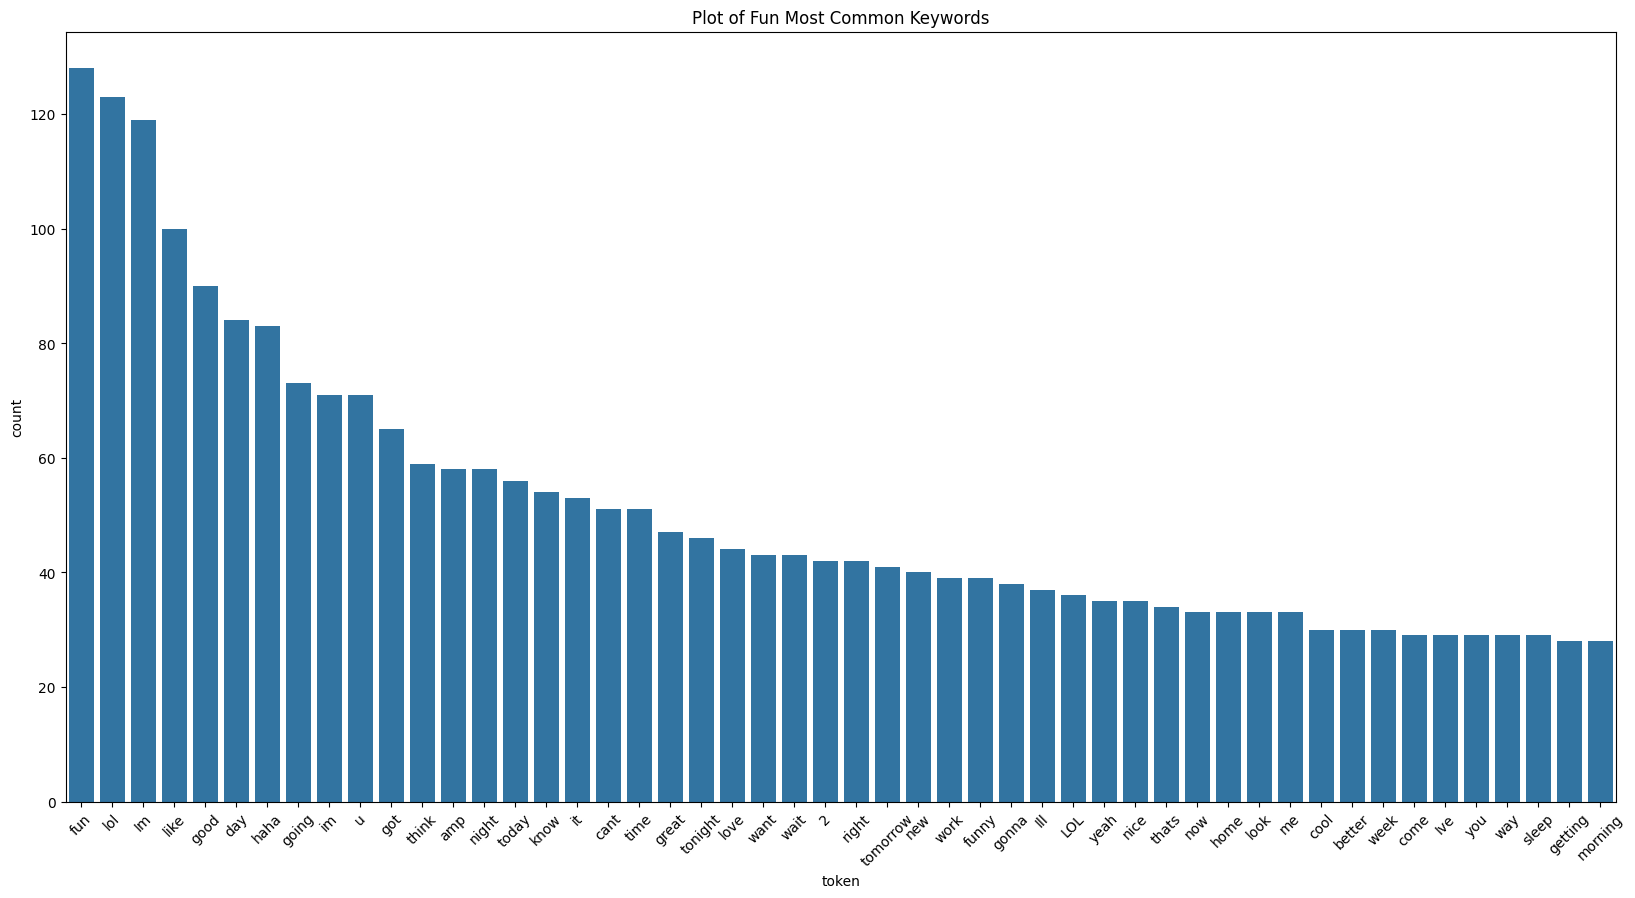

In [45]:
plot_most_common_words(keyword_fun , "Fun")

In [46]:
# Word Cloud
from wordcloud import WordCloud

In [47]:
# Function to generate and display word cloud for a given text document
def plot_wordcloud(docx):
    
    # Generate word cloud from text
    mywordcloud = WordCloud().generate(docx)
    
    # Set figure size
    plt.figure(figsize=(20,10))
    
    # Display word cloud image
    plt.imshow(mywordcloud, interpolation='bilinear')
    
    # Remove axis for better visualization
    plt.axis('off')
    
    plt.show()

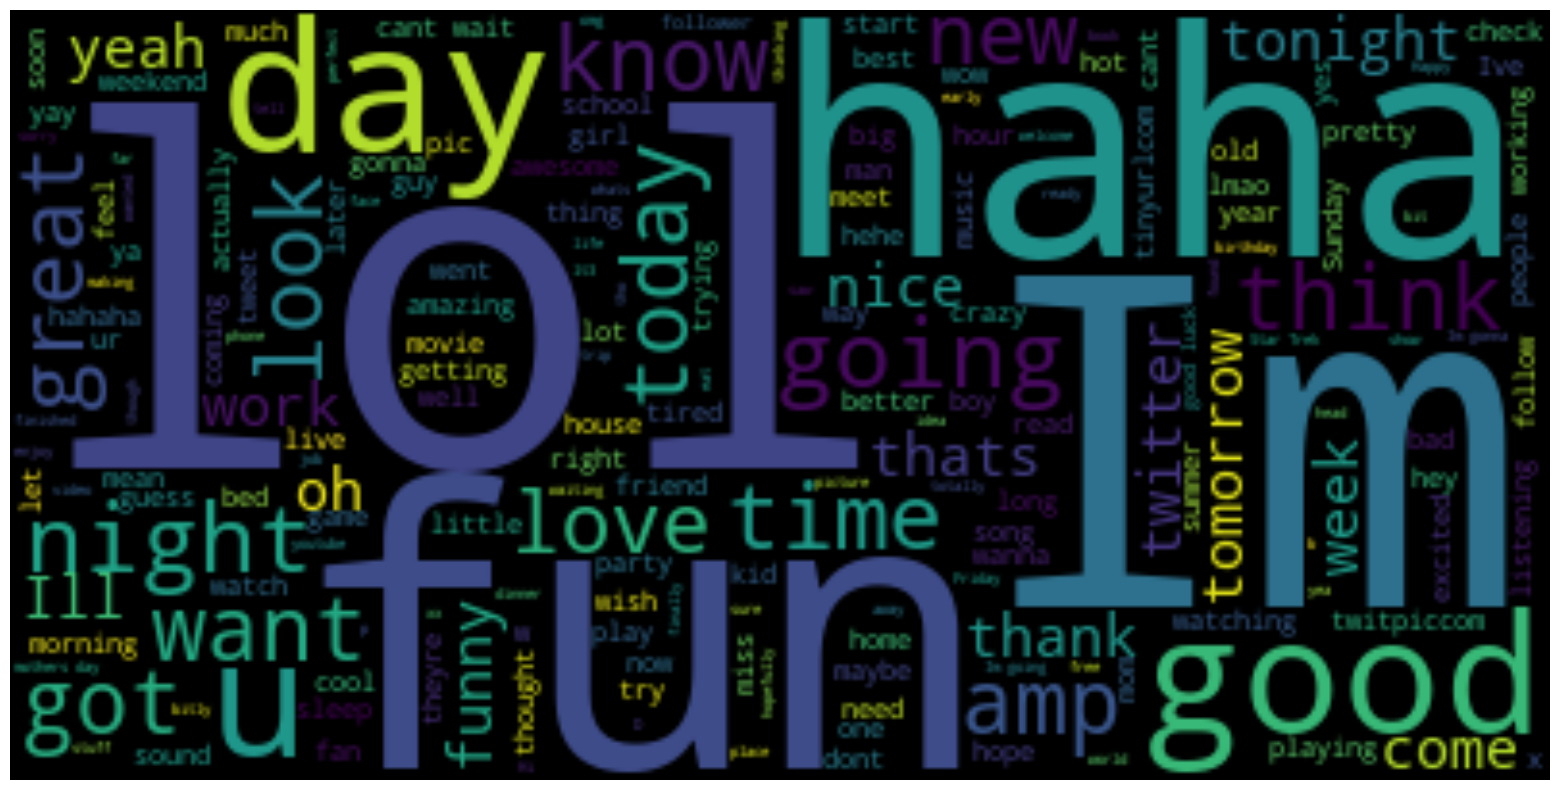

In [48]:
plot_wordcloud(fun_docx)

# Machine Learning
+ Logistic regression
+ Knn
+ Decision tree

In [50]:
!pip install scikit-learn

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
# load ML PKgs
# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Import text vectorization techniques
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Import function to split dataset into train and test sets
from sklearn.model_selection import train_test_split

# Build Feature From Our Text

In [54]:
# Define input features (cleaned text)
Xfeatures = df['Clean_content']

# Define target labels (emotion categories)
ylabels = df['Emotion']

In [55]:
Xfeatures

0          know listenin bad habit earlier started frea...
1                   Layin n bed headache ughhhhwaitin call
2                            Funeral ceremonygloomy friday
3                                  wants hang friends SOON
4                          want trade Houston tickets will
                               ...                        
39995                                                     
39996                               Happy Mothers Day love
39997    Happy Mothers Day mommies there woman man long...
39998      WASSUP BEAUTIFUL FOLLOW ME PEEP NEW HIT SING...
39999      bullet train tokyo gf visiting japan thursda...
Name: Clean_content, Length: 40000, dtype: object

In [56]:
# Initialize CountVectorizer for Bag-of-Words representation
cv = CountVectorizer()

# Learn vocabulary and transform text into numeric feature matrix
X = cv.fit_transform(Xfeatures)

In [57]:
# Display vocabulary (feature names) learned by CountVectorizer
cv.get_feature_names_out()

array(['00', '000', '002', ..., '½you', '½z', '½ï'],
      shape=(37205,), dtype=object)

In [58]:
# Spliting The Dataset
X_train,X_test,y_train,y_test = train_test_split(X,ylabels,test_size=0.3,random_state=42)

# Building Model

In [60]:
nv_model =  MultinomialNB() 
nv_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [61]:
# Accuracy
nv_model.score(X_test, y_test)

0.31575

In [62]:
lr_model =  LogisticRegression() 
lr_model.fit(X_train, y_train)

C:\Users\hp\anaconda3\envs\nlp_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
# Accuracy 
lr_model.score(X_test,y_test)

0.33275

In [64]:
# Predictions
y_pred_for_lr = lr_model.predict(X_test)

In [65]:
y_pred_for_lr

array(['neutral', 'neutral', 'worry', ..., 'neutral', 'neutral',
       'sadness'], shape=(12000,), dtype=object)

# Making A Single Prediction
+ Vectorized our Text
+ Applied our model

In [67]:
sample_text = ["I Really Love Coding Very Much"]

In [68]:
vect = cv.transform(sample_text).toarray()

In [69]:
# Make Prediction
lr_model.predict(vect)

array(['surprise'], dtype=object)

In [70]:
# Checking For Prediction Percentage (Probability)/ Confidence Score
lr_model.predict_proba(vect)

array([[0.00112273, 0.01149029, 0.01290517, 0.00333359, 0.0162057 ,
        0.02969865, 0.01650234, 0.27122091, 0.0380478 , 0.00694289,
        0.10846268, 0.36556676, 0.11850048]])

In [71]:
# Get All Class for our Model
lr_model.classes_

array(['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness',
       'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise',
       'worry'], dtype=object)

In [72]:
np.max(lr_model.predict_proba(vect))

np.float64(0.3655667564316717)

In [73]:
def predict_emotion(sample_text, model):
    myvect = cv.transform([sample_text]).toarray()
    prediction = model.predict(myvect)
    pred_proba = model.predict_proba(myvect)
    
    pred_percentage_for_all = dict(zip(model.classes_, pred_proba[0]))
    
    print("Prediction:", prediction[0])
    print("Prediction Score:", np.max(pred_proba))
    
    return pred_percentage_for_all

In [74]:
predict_emotion("I am extremely happy today", lr_model)

Prediction: happiness
Prediction Score: 0.43601825326260474


{'anger': np.float64(0.0004628398443148169),
 'boredom': np.float64(0.0019584504336585405),
 'empty': np.float64(0.0051764286486966305),
 'enthusiasm': np.float64(0.01039029866320636),
 'fun': np.float64(0.01630041744626043),
 'happiness': np.float64(0.43601825326260474),
 'hate': np.float64(0.004772424047087674),
 'love': np.float64(0.1652244871316415),
 'neutral': np.float64(0.01813309846430484),
 'relief': np.float64(0.07961894051766953),
 'sadness': np.float64(0.07405075548058045),
 'surprise': np.float64(0.010498074994823931),
 'worry': np.float64(0.17739553106515066)}

In [75]:
predict_emotion("i hate coding so much at night",lr_model)

Prediction: hate
Prediction Score: 0.407715916426459


{'anger': np.float64(0.00033919616247461855),
 'boredom': np.float64(0.004532085992747068),
 'empty': np.float64(0.012358592754088293),
 'enthusiasm': np.float64(0.006950556117201695),
 'fun': np.float64(0.012127718223369562),
 'happiness': np.float64(0.019051267482707426),
 'hate': np.float64(0.407715916426459),
 'love': np.float64(0.01937247261873237),
 'neutral': np.float64(0.2835832691903072),
 'relief': np.float64(0.0038593551569459615),
 'sadness': np.float64(0.12293803436522313),
 'surprise': np.float64(0.00797997442466471),
 'worry': np.float64(0.09919156108507908)}

# Model Evaluation

In [77]:
# Classification
print(classification_report(y_test,y_pred_for_lr))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        33
     boredom       0.00      0.00      0.00        57
       empty       0.09      0.01      0.02       242
  enthusiasm       0.24      0.02      0.03       249
         fun       0.12      0.05      0.07       513
   happiness       0.33      0.32      0.33      1568
        hate       0.34      0.17      0.23       383
        love       0.43      0.39      0.41      1134
     neutral       0.35      0.56      0.43      2620
      relief       0.23      0.05      0.09       515
     sadness       0.31      0.26      0.29      1560
    surprise       0.19      0.08      0.11       625
       worry       0.33      0.40      0.36      2501

    accuracy                           0.33     12000
   macro avg       0.23      0.18      0.18     12000
weighted avg       0.31      0.33      0.31     12000



C:\Users\hp\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [78]:
# Confusion
confusion_matrix(y_test,y_pred_for_lr)

array([[   0,    0,    0,    0,    0,    3,    0,    1,   12,    0,    4,
           1,   12],
       [   0,    0,    0,    2,    0,    4,    2,    2,   16,    0,   14,
           1,   16],
       [   0,    2,    2,    0,    1,   19,    6,    4,  135,    1,   20,
           3,   49],
       [   0,    0,    0,    4,    9,   31,    4,   10,  109,    1,   20,
           6,   55],
       [   0,    0,    0,    0,   27,  132,    4,   32,  163,    4,   37,
          15,   99],
       [   0,    0,    1,    3,   48,  507,    4,  188,  468,   19,   80,
          27,  223],
       [   0,    0,    0,    0,    3,   11,   66,    2,   98,    2,   84,
           7,  110],
       [   0,    0,    0,    2,   18,  207,    6,  441,  247,   14,   50,
          21,  128],
       [   0,    2,    7,    2,   33,  213,   19,  111, 1468,   17,  160,
          48,  540],
       [   0,    0,    0,    0,    7,   92,    3,   42,  182,   27,   38,
           9,  115],
       [   0,    1,    8,    2,   26,   81,   36, 

In [79]:
from sklearn.linear_model import LogisticRegression

In [82]:
Xfeatures = df['Clean_content']
ylabels = df['Emotion']

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    Xfeatures, ylabels, test_size=0.2, random_state=42
)

In [86]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

In [88]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Accuracy: 0.3325


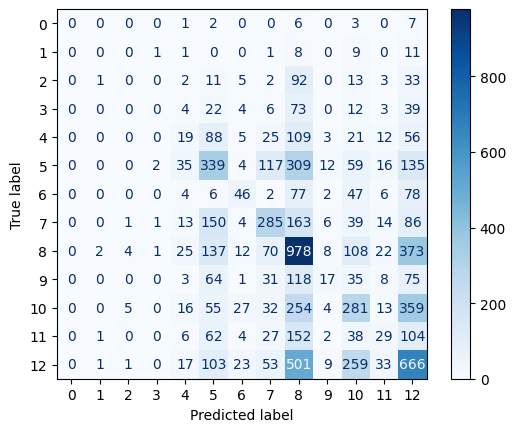

In [92]:
# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_vec, y_train)

# Predict
y_pred = lr_model.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.show()

In [94]:
import joblib

In [96]:
# Save the trained model
joblib.dump(lr_model, "text_emotion_analysis.pkl")
print("Model saved successfully!")

Model saved successfully!


In [98]:
import pickle

In [100]:
filename = 'Text_Emotion_analysis.sav'
pickle.dump(lr_model, open(filename, 'wb'))

In [102]:
# loading the saved model
loaded_model = pickle.load(open('Text_EMotion_analysis.sav', 'rb'))